# Phase 10: correlation-matrix processes with exact finite-time law

Computational record for `PHASE_10_MATRIX.md`. The **Phase-Gram
construction**: drive the canonical triangular angles of the Gram
parameterization (Rebonato–Jäckel 1999; Rapisarda–Brigo–Mercurio
2002) with *independent Brownian motions*. Then:

- \(R_t=B(\theta_t)B(\theta_t)^\top\) is PSD with unit diagonal by
  construction — no boundary conditions (contrast Jacobi matrix
  diffusions);
- the angle vector is jointly Gaussian, so **every** European
  functional \(\mathbb E[h(R_T)]\) reduces to a
  \(d=n(n-1)/2\)-dimensional Gauss–Hermite product quadrature;
- pairwise marginals are closed form (\(\cos\) of a Gaussian);
- for \(n=3\) the induced Itô drift of the free entry is analytic:
  \(\mu_{R_{23}}=-\tfrac12(\sigma_\alpha^2+\sigma_\beta^2)R_{23}
  -\tfrac12\sigma_\gamma^2\sin\alpha\sin\beta\cos\gamma\).

In [1]:
from pathlib import Path
import json, math, platform, sys, time

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import scipy

ROOT = Path.cwd().resolve()
if not (ROOT / "phase10_matrix.py").exists():
    candidates = [ROOT, *ROOT.parents]
    ROOT = next(p for p in candidates if (p / "phase10_matrix.py").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import phase10_matrix as p10

SEED = 20260821
FIGURES = ROOT / "phase10_figures"
FIGURES.mkdir(exist_ok=True)

SIGMAS = np.array([0.8, 0.6, 0.7])       # sigma_alpha, sigma_beta, sigma_gamma
ANGLES0 = np.array([0.3, -0.2, 0.5])
MATURITY = 1.0

environment = {
    "python": platform.python_version(),
    "numpy": np.__version__,
    "scipy": scipy.__version__,
    "matplotlib": matplotlib.__version__,
    "platform": platform.platform(),
    "seed": SEED,
}
print(json.dumps(environment, indent=2))
started = time.time()

{
  "python": "3.12.13",
  "numpy": "2.5.1",
  "scipy": "1.18.0",
  "matplotlib": "3.11.1",
  "platform": "Linux-7.2.0-1-cachyos-x86_64-with-glibc2.44",
  "seed": 20260821
}


## 1. The angle map and its geometry

Static view: \(R_{23}\) as a function of \((\alpha,\beta)\) at fixed
\(\gamma=0\), plus a random slice of generated matrices verifying PSD.

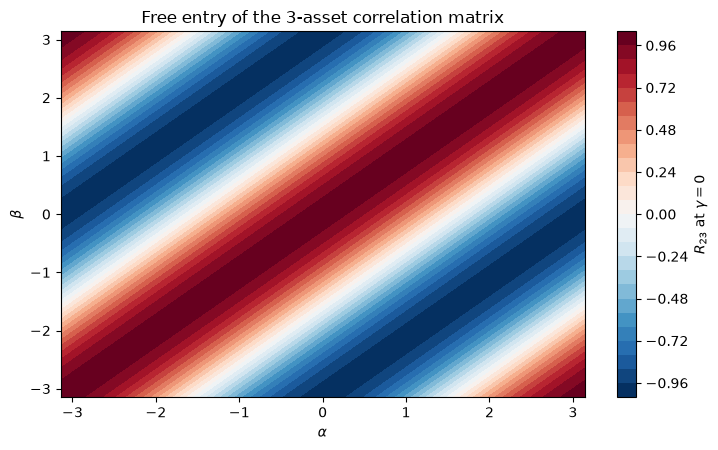

min eigenvalue over 2000 random matrices: 3.99e-10


In [2]:
alphas = np.linspace(-math.pi, math.pi, 120)
betas = np.linspace(-math.pi, math.pi, 120)
A, Bgrid = np.meshgrid(alphas, betas)
R23_surface = np.cos(A) * np.cos(Bgrid) + np.sin(A) * np.sin(Bgrid)

fig, ax = plt.subplots(figsize=(7.4, 4.6))
cs = ax.contourf(A, Bgrid, R23_surface, levels=30, cmap="RdBu_r", vmin=-1, vmax=1)
fig.colorbar(cs, label=r"$R_{23}$ at $\gamma=0$")
ax.set_xlabel(r"$\alpha$"); ax.set_ylabel(r"$\beta$")
ax.set_title("Free entry of the 3-asset correlation matrix")
fig.tight_layout()
fig.savefig(FIGURES / "phase10_map.png", dpi=150)
plt.show()

rng = np.random.default_rng(SEED)
eigs_min = []
for _ in range(2000):
    angles = rng.uniform(-math.pi, math.pi, 3)
    corr = p10.correlation_from_angles(angles, 3)
    eigs_min.append(np.linalg.eigvalsh(corr).min())
print(f"min eigenvalue over 2000 random matrices: {min(eigs_min):.2e}")

## 2. Exact marginals vs Monte Carlo

\(R_{12}=\cos\alpha\) has the closed-form Gaussian-cosine law;
\(R_{23}\) is handled by exact Gauss–Hermite over the joint Gaussian
angle law.

In [3]:
paths = p10.simulate_angle_system(
    maturity=MATURITY, volatilities=SIGMAS, initial_angles=ANGLES0,
    n_steps=200, n_paths=300000, seed=SEED)

mean_exact, sd_exact = p10.pairwise_marginal_cos_gaussian(
    ANGLES0[0], SIGMAS[0], MATURITY)
sample12 = np.cos(paths[:, -1, 0])
se = sample12.std() / math.sqrt(sample12.size)
print(f"R12 mean: exact {mean_exact:.5f}  MC {sample12.mean():.5f} ({se:.5f})")
print(f"R12 sd  : exact {sd_exact:.5f}  MC {sample12.std():.5f}")

mean_gh = p10.gh_expectation(
    lambda pts: p10.r23_entry(pts[:, 0], pts[:, 1], pts[:, 2]),
    mean=ANGLES0, stds=SIGMAS * math.sqrt(MATURITY), n_points=30)
second_gh = p10.gh_expectation(
    lambda pts: p10.r23_entry(pts[:, 0], pts[:, 1], pts[:, 2]) ** 2,
    mean=ANGLES0, stds=SIGMAS * math.sqrt(MATURITY), n_points=30)
sample23 = p10.r23_entry(paths[:, -1, 0], paths[:, -1, 1], paths[:, -1, 2])
se23 = sample23.std() / math.sqrt(sample23.size)
print(f"R23 mean: GH {mean_gh:.5f}  MC {sample23.mean():.5f} ({se23:.5f})")
print(f"R23 sd  : GH {math.sqrt(second_gh - mean_gh**2):.5f}  MC {sample23.std():.5f}")

R12 mean: exact 0.69372  MC 0.69374 (0.00067)
R12 sd  : exact 0.36537  MC 0.36537


R23 mean: GH 0.54343  MC 0.54432 (0.00082)
R23 sd  : GH 0.45116  MC 0.45059


## 3. Itô drift verification

Short-horizon empirical drift of \(R_{23}\) against the analytic
formula, across several starting states.

In [4]:
dt = 1e-3
starts = [np.array([0.3, -0.2, 0.5]), np.array([1.0, 0.8, -0.6]),
          np.array([-0.9, 0.4, 1.2])]
rows = []
for start in starts:
    sim = p10.simulate_angle_system(
        maturity=dt, volatilities=SIGMAS, initial_angles=start,
        n_steps=1, n_paths=400000, seed=SEED + int(start[0] * 100))
    sample = p10.r23_entry(sim[:, -1, 0], sim[:, -1, 1], sim[:, -1, 2])
    start_val = float(p10.r23_entry(*start))
    empirical = (float(sample.mean()) - start_val) / dt
    analytic = p10.r23_drift(start[0], start[1], start[2],
                             sig_a=SIGMAS[0], sig_b=SIGMAS[1],
                             sig_g=SIGMAS[2])
    rows.append((start.copy(), start_val, empirical, analytic))

for start, sv, emp, ana in rows:
    print(f"start {np.round(start,2)}: R23(0)={sv:+.4f}  "
          f"empirical drift {emp:+.4f}  analytic {ana:+.4f}")

start [ 0.3 -0.2  0.5]: R23(0)=+0.8848  empirical drift -0.4316  analytic -0.4298
start [ 1.   0.8 -0.6]: R23(0)=+0.8746  empirical drift -0.5589  analytic -0.5594
start [-0.9  0.4  1.2]: R23(0)=+0.4620  empirical drift -0.2212  analytic -0.2039


## 4. Correlation derivatives: exact pricing table

Digitals and calls on the free entry \(R_{23}(T)\), and an average
pairwise-correlation payoff, priced by Gauss–Hermite vs Monte Carlo.
Also: the exact term structure of \(\mathbb E[R_{23}(t)]\).

call on R23(T):


  K=-0.2: GH 0.77088  MC 0.77159 (0.00070)


  K=+0.0: GH 0.59329  MC 0.59381 (0.00063)


  K=+0.2: GH 0.42673  MC 0.42727 (0.00053)


  K=+0.4: GH 0.27566  MC 0.27601 (0.00041)


  K=+0.6: GH 0.14564  MC 0.14598 (0.00028)

digital on R23(T) >= 0.4:


  GH 0.71248  MC 0.70950


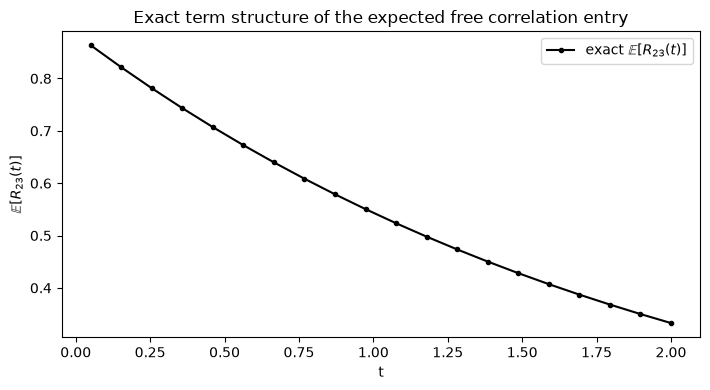

In [5]:
def mc_price(payoff):
    return float(np.mean(payoff(sample23)))

strike_grid = [-0.2, 0.0, 0.2, 0.4, 0.6]
print("call on R23(T):")
for k in strike_grid:
    gh = p10.gh_expectation(
        lambda pts, kk=k: np.maximum(p10.r23_entry(pts[:, 0], pts[:, 1], pts[:, 2]) - kk, 0),
        mean=ANGLES0, stds=SIGMAS * math.sqrt(MATURITY), n_points=40)
    mcc = mc_price(lambda s, kk=k: np.maximum(s - kk, 0))
    se_c = float((np.maximum(sample23 - k, 0)).std() / math.sqrt(sample23.size))
    print(f"  K={k:+.1f}: GH {gh:.5f}  MC {mcc:.5f} ({se_c:.5f})")

print("\ndigital on R23(T) >= 0.4:")
gh_d = p10.gh_expectation(
    lambda pts: (p10.r23_entry(pts[:, 0], pts[:, 1], pts[:, 2]) >= 0.4).astype(float),
    mean=ANGLES0, stds=SIGMAS * math.sqrt(MATURITY), n_points=40)
mc_d = mc_price(lambda s: (s >= 0.4).astype(float))
print(f"  GH {gh_d:.5f}  MC {mc_d:.5f}")

# Term structure of E[R23(t)] via GH at several horizons
horizons = np.linspace(0.05, 2.0, 20)
term = [
    p10.gh_expectation(
        lambda pts: p10.r23_entry(pts[:, 0], pts[:, 1], pts[:, 2]),
        mean=ANGLES0, stds=SIGMAS * math.sqrt(h), n_points=25)
    for h in horizons
]
fig, ax = plt.subplots(figsize=(7.2, 4.0))
ax.plot(horizons, term, "k-o", ms=3, label=r"exact $\mathbb{E}[R_{23}(t)]$")
ax.set_xlabel("t"); ax.set_ylabel(r"$\mathbb{E}[R_{23}(t)]$")
ax.set_title("Exact term structure of the expected free correlation entry")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / "phase10_term_structure.png", dpi=150)
plt.show()

## 5. Record

All European quantities are deterministic quadratures; Monte Carlo
appears only as benchmark. Figures in `phase10_figures/`.

In [6]:
elapsed = time.time() - started
print(f"notebook executed in {elapsed:.1f} s")

notebook executed in 7.1 s
